## 1) Initialisation & Chargement des données

#### Creation de la Spark Session

In [1]:
import os, sys
from pyspark.sql import SparkSession

# 1. Alignement de l'exécutable Python (évite les conflits d'environnements)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 2. Fix notebook Windows / Py4J
os.environ["PYSPARK_PIN_THREAD"] = "true"

# 3. Construction de la Session Spark
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("WinLocalhostOnly")
    .config("spark.ui.enabled", "false")
    # Force localhost partout
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.local.ip", "127.0.0.1")
    # Force IPv4 JVM
    .config("spark.driver.extraJavaOptions", "-Djava.net.preferIPv4Stack=true")
    .config("spark.executor.extraJavaOptions", "-Djava.net.preferIPv4Stack=true")
    # Evite certains soucis worker Windows
    .config("spark.python.use.daemon", "true")
    .config("spark.python.worker.reuse", "true")
    # Alloue 4 Go (ou plus selon ta RAM)
    .config("spark.driver.memory", "4g") 
    .getOrCreate()
)

#### Chargement du Data Set

In [2]:
# Lecture du CSV avec détection automatique du schéma et présence d'en-tête
df = spark.read.csv("Online_Retail_CSV.csv", header=True, inferSchema=True, sep=";")
df.show(5)

+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|     InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
|   536365|   85123A|WHITE HANGING HEA...|       6|01/12/2010 08:26|     2,55|     17850|United Kingdom|
|   536365|    71053| WHITE METAL LANTERN|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84406B|CREAM CUPID HEART...|       8|01/12/2010 08:26|     2,75|     17850|United Kingdom|
|   536365|   84029G|KNITTED UNION FLA...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
|   536365|   84029E|RED WOOLLY HOTTIE...|       6|01/12/2010 08:26|     3,39|     17850|United Kingdom|
+---------+---------+--------------------+--------+----------------+---------+----------+--------------+
only showing top 5 rows



#### Vérification de la structure et nombre de lignes

In [3]:
# Affichage du schéma (structure des colonnes)
print("--- Schéma du DataFrame ---")
df.printSchema()

# Comptage du nombre de lignes
row_count = df.count()
col_count = len(df.columns)

print(f"--- Statistiques de base ---")
print(f"Nombre de lignes : {row_count}")
print(f"Nombre de colonnes : {col_count}")

--- Schéma du DataFrame ---
root
 |-- InvoiceNo: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: string (nullable = true)
 |-- UnitPrice: string (nullable = true)
 |-- CustomerID: integer (nullable = true)
 |-- Country: string (nullable = true)

--- Statistiques de base ---
Nombre de lignes : 541909
Nombre de colonnes : 8


## 2) Exploration & Prétraitement


#### Statistiques descriptives

In [4]:
from pyspark.sql.functions import countDistinct, col, desc

# 1. Nombre de clients distincts
unique_customers = df.select(countDistinct("CustomerID")).collect()[0][0]
print(f"Nombre de clients uniques : {unique_customers}")

# 2. Distribution de la colonne Quantity
# Trois types de valeurs négatives possibles : annulation/retour, correction de pertes, frais de remise.
print("Statistiques descriptives de la quantité de ventes :")
df_sales_only = df.filter(col("Quantity") > 0)
df_sales_only.select("Quantity").summary().show()

print("Statistiques descriptives des quantités négatives")
df_returns = df.filter(col("Quantity") < 0)
df_returns.select("Quantity").summary().show()



# 3. Top 10 des produits les plus vendus (pour le contexte)
df.groupBy("Description").sum("Quantity") \
    .withColumnRenamed("sum(Quantity)", "Total_Qty") \
    .orderBy(desc("Total_Qty")).show(10)

Nombre de clients uniques : 4372
Statistiques descriptives de la quantité de ventes :
+-------+------------------+
|summary|          Quantity|
+-------+------------------+
|  count|            531285|
|   mean|10.655262241546438|
| stddev|156.83032303670885|
|    min|                 1|
|    25%|                 1|
|    50%|                 3|
|    75%|                10|
|    max|             80995|
+-------+------------------+

Statistiques descriptives des quantités négatives
+-------+------------------+
|summary|          Quantity|
+-------+------------------+
|  count|             10624|
|   mean|-45.60721009036145|
| stddev|   1092.2142164236|
|    min|            -80995|
|    25%|               -10|
|    50%|                -2|
|    75%|                -1|
|    max|                -1|
+-------+------------------+

+--------------------+---------+
|         Description|Total_Qty|
+--------------------+---------+
|WORLD WAR 2 GLIDE...|    53847|
|JUMBO BAG RED RET...|    47363|
|

#### Nettoyage de valeurs négatives sur la colonne Quantité

In [5]:
from pyspark.sql import functions as F

# Filtrer les retours (quantités négatives)
df = df.filter(F.col("Quantity") > 0)

print(f"Nombre de lignes après nettoyage : {df.count()}")

Nombre de lignes après nettoyage : 531285


#### Nettoyage des valeurs manquantes

In [6]:
from pyspark.sql.functions import isnan, when, count, col

# Compter les Nulls par colonne
df.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---------+---------+-----------+--------+-----------+---------+----------+-------+
|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country|
+---------+---------+-----------+--------+-----------+---------+----------+-------+
|        0|        0|        592|       0|          0|        0|    133361|      0|
+---------+---------+-----------+--------+-----------+---------+----------+-------+



In [7]:
# 1. Suppression des lignes où CustomerID est nul car sans CustomerID il n'est pas possible de faire la segmentation.
df_cleaned = df.filter(col("CustomerID").isNotNull())

# 3. Suppression des doublons potentiels
df_cleaned = df_cleaned.dropDuplicates()

print(f"Nombre de lignes après nettoyage : {df_cleaned.count()}")

Nombre de lignes après nettoyage : 392732


#### Conversion colonne 'InvoiceDate' en Timestamp

In [8]:
from pyspark.sql import functions as F

# Convertit une colonne texte "date_brute" en type Timestamp
df_cleaned = df_cleaned.withColumn("InvoiceDate", F.to_timestamp(F.col("InvoiceDate"), "dd/MM/yyyy HH:mm"))
df_cleaned.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   536367|    22748|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2,1|     13047|United Kingdom|
|   536375|    22752|SET 7 BABUSHKA NE...|       2|2010-12-01 09:32:00|     7,65|     17850|United Kingdom|
|   536385|    22783|SET 3 WICKER OVAL...|       1|2010-12-01 09:56:00|    19,95|     17420|United Kingdom|
|   536406|    82486|WOOD S/3 CABINET ...|       4|2010-12-01 11:33:00|     6,95|     17850|United Kingdom|
|   536409|    21823|PAINTED METAL HEA...|       3|2010-12-01 11:45:00|     1,45|     17908|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows



#### Création de la colonne 'Total'

In [9]:
df_cleaned = df_cleaned.withColumn("UnitPrice", 
    F.regexp_replace(F.col("UnitPrice"), ",", ".").cast("double") )

df_cleaned = df_cleaned.withColumn("Total", F.round(F.col("Quantity") * F.col("UnitPrice"), 2) )

df_cleaned.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|Total|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+-----+
|   536367|    22748|POPPY'S PLAYHOUSE...|       6|2010-12-01 08:34:00|      2.1|     13047|United Kingdom| 12.6|
|   536375|    22752|SET 7 BABUSHKA NE...|       2|2010-12-01 09:32:00|     7.65|     17850|United Kingdom| 15.3|
|   536385|    22783|SET 3 WICKER OVAL...|       1|2010-12-01 09:56:00|    19.95|     17420|United Kingdom|19.95|
|   536406|    82486|WOOD S/3 CABINET ...|       4|2010-12-01 11:33:00|     6.95|     17850|United Kingdom| 27.8|
|   536409|    21823|PAINTED METAL HEA...|       3|2010-12-01 11:45:00|     1.45|     17908|United Kingdom| 4.35|
+---------+---------+--------------------+--------+-------------------+---------+-------

## 3) Segmentation Client (Non Supervisé)

#### Création de variables RFM (Recency, Frequency, Monetary) 

In [10]:
from pyspark.sql import functions as F

# 1. On récupère la date la plus récente du dataset
date_max = df_cleaned.select(F.max("InvoiceDate")).collect()[0][0]

# 2. Calcul RFM avec Recency en minutes
rfm_df = df_cleaned.groupBy("CustomerID").agg(
    # (Secondes totales / 86400 secondes par jour) car pour la segmentation l'algorithme a besoin des nombres réels.
    F.round(
        (F.unix_timestamp(F.lit(date_max)) - F.unix_timestamp(F.max("InvoiceDate"))) / 86400, 4).alias("Recency"), 
    F.countDistinct("InvoiceNo").alias("Frequency"),
    F.round(F.sum("Total"), 2).alias("Monetary")
)

rfm_df.show(10)

+----------+--------+---------+--------+
|CustomerID| Recency|Frequency|Monetary|
+----------+--------+---------+--------+
|     15619| 10.1917|        1|   336.4|
|     17389|  0.1333|       34|31833.68|
|     14450|180.1278|        3|  483.25|
|     15727| 16.0097|        7| 5159.06|
|     15790|  9.9146|        1|  218.75|
|     13285| 22.9799|        4| 2709.12|
|     14570|280.0778|        2|  218.06|
|     16574| 71.0076|        1|  451.44|
|     13623| 30.0347|        5|  727.74|
|     15957|  31.025|        1|  428.89|
+----------+--------+---------+--------+
only showing top 10 rows



#### Statistiques descriptives des colonnes RFM

In [11]:
rfm_df.select("Recency", "Frequency", "Monetary").describe().show()

+-------+-----------------+-----------------+------------------+
|summary|          Recency|        Frequency|          Monetary|
+-------+-----------------+-----------------+------------------+
|  count|             4339|             4339|              4339|
|   mean|92.04960430974864|4.271952062687255|2048.2159230237457|
| stddev| 100.013308454442|7.705492771314808| 8984.248351745262|
|    min|              0.0|                1|               0.0|
|    max|         373.1229|              210|         280206.02|
+-------+-----------------+-----------------+------------------+



#### Visualisation de la distribution des variables RFM

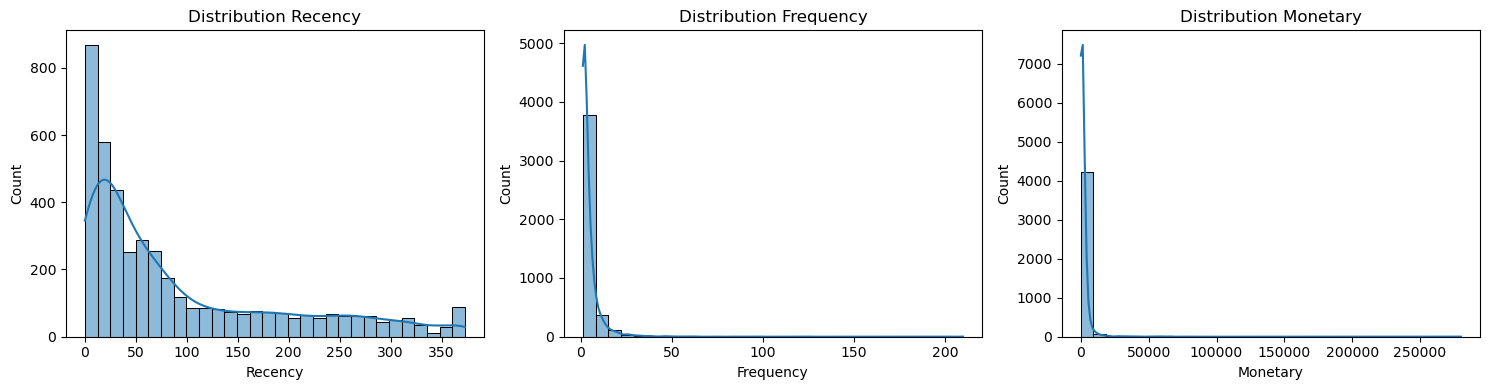

In [12]:
# Sélection des colonnes utiles
rfm_selected = rfm_df.select("Recency", "Frequency", "Monetary")

# Conversion vers pandas
rfm_pd = rfm_selected.toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm_pd["Recency"], bins=30, kde=True)
plt.title("Distribution Recency")

plt.subplot(1,3,2)
sns.histplot(rfm_pd["Frequency"], bins=30, kde=True)
plt.title("Distribution Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm_pd["Monetary"], bins=30, kde=True)
plt.title("Distribution Monetary")

plt.tight_layout()
plt.show()

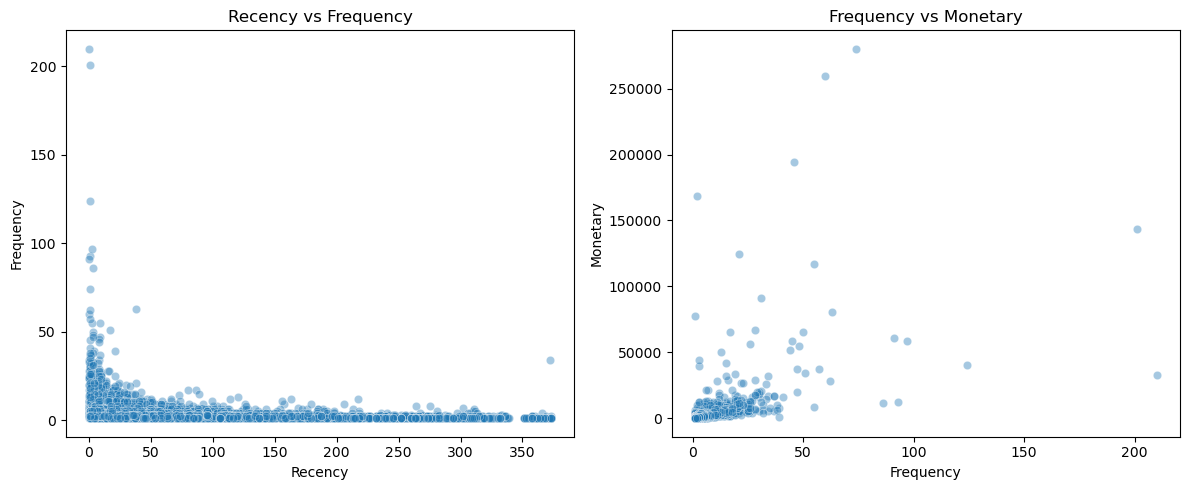

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(data=rfm_pd, x="Recency", y="Frequency", alpha=0.4)
plt.title("Recency vs Frequency")

plt.subplot(1,2,2)
sns.scatterplot(data=rfm_pd, x="Frequency", y="Monetary", alpha=0.4)
plt.title("Frequency vs Monetary")

plt.tight_layout()
plt.show()

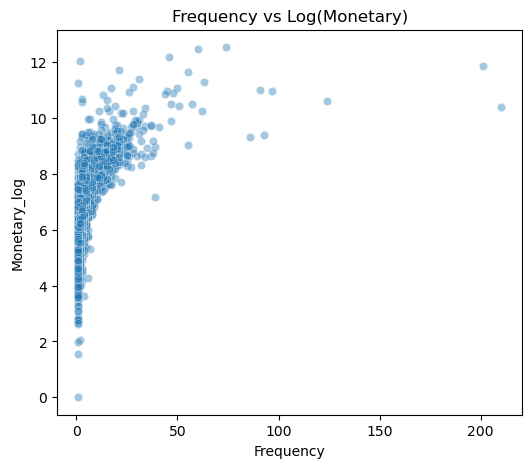

In [14]:
import numpy as np

rfm_pd["Monetary_log"] = np.log1p(rfm_pd["Monetary"])

plt.figure(figsize=(6,5))
sns.scatterplot(data=rfm_pd, x="Frequency", y="Monetary_log", alpha=0.4)
plt.title("Frequency vs Log(Monetary)")
plt.show()

#### Suppression des valeurs du 1% supérieur

In [15]:
''' Des lignes avec monetary<0 et recency=0 sont des "polluants" statistiques qui peuvent fausser complètement ton modèle de clustering. 

1. Pourquoi c'est un problème ?
Monetary < 0 : Cela correspond généralement à des retours de marchandises ou des annulations de factures. 
Si tu gardes ces valeurs, le modèle K-Means va créer un cluster bizarre pour les "clients négatifs", ce qui n'a pas de sens marketing.

Recency = 0 : Ce sont tes clients les plus récents (ils ont commandé le jour même de ton point de référence). 
Le problème n'est pas le 0 en soi, mais le fait que si tu as beaucoup de 0, la distribution de tes données est très écrasée, ce qui peut perturber le calcul des distances. '''

# 1. Nettoyage des données aberrantes
rfm_df_cleaned = rfm_df.filter((F.col("Monetary") > 0) & (F.col("Frequency") > 0))

# 2. Optionnel : Traitement des outliers extrêmes (ex: le top 1% de Monetary)
# Certains clients dépensent des millions et écrasent les autres.
# On peut les plafonner ou les isoler.
quantile_99 = rfm_df_cleaned.stat.approxQuantile("Monetary", [0.99], 0.01)[0]
rfm_df_cleaned = rfm_df_cleaned.filter(F.col("Monetary") <= quantile_99)

#### Visualisation de données propres

In [16]:
# Sélection des colonnes utiles
rfm_selected_2 = rfm_df_cleaned.select("Recency", "Frequency", "Monetary")

# Conversion vers pandas
rfm_pd_2 = rfm_selected_2.toPandas()

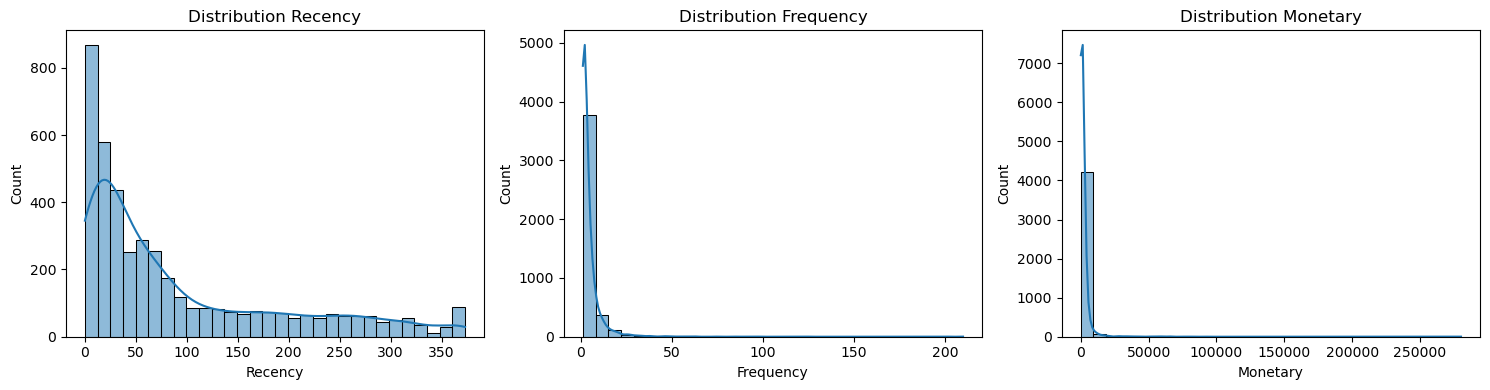

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm_pd_2["Recency"], bins=30, kde=True)
plt.title("Distribution Recency")

plt.subplot(1,3,2)
sns.histplot(rfm_pd_2["Frequency"], bins=30, kde=True)
plt.title("Distribution Frequency")

plt.subplot(1,3,3)
sns.histplot(rfm_pd_2["Monetary"], bins=30, kde=True)
plt.title("Distribution Monetary")

plt.tight_layout()
plt.show()

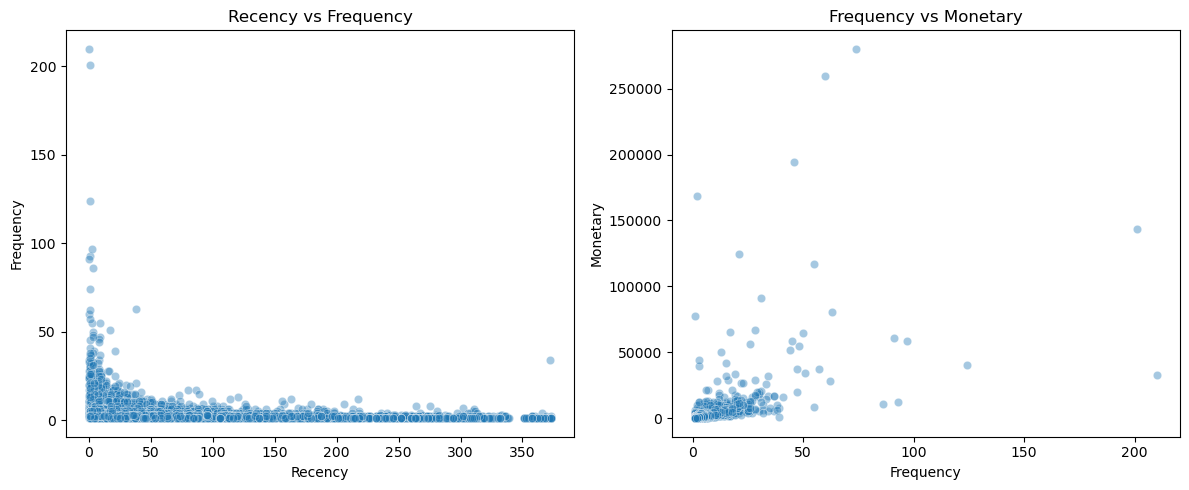

In [18]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.scatterplot(data=rfm_pd_2, x="Recency", y="Frequency", alpha=0.4)
plt.title("Recency vs Frequency")

plt.subplot(1,2,2)
sns.scatterplot(data=rfm_pd_2, x="Frequency", y="Monetary", alpha=0.4)
plt.title("Frequency vs Monetary")

plt.tight_layout()
plt.show()

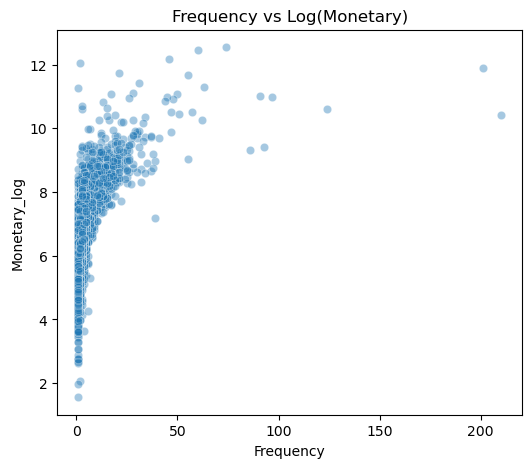

In [19]:
rfm_pd_2["Monetary_log"] = np.log1p(rfm_pd_2["Monetary"])

plt.figure(figsize=(6,5))
sns.scatterplot(data=rfm_pd_2, x="Frequency", y="Monetary_log", alpha=0.4)
plt.title("Frequency vs Log(Monetary)")
plt.show()

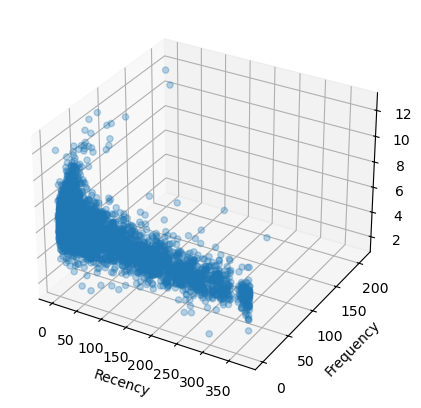

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm_pd_2["Recency"],
    rfm_pd_2["Frequency"],
    rfm_pd_2["Monetary_log"],
    alpha=0.3
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Log Monetary")

plt.show()

#### Assemblage et standardisation

In [21]:
# Pour passer à la segmentation (K-Means), Spark exige que tes données soient transformées en un seul vecteur. 
# De plus, comme la Recency (ex: 0.5 jours) n'a pas la même échelle que le Monetary (ex: 5000 €), 
# le StandardScaler est indispensable pour que le prix n'écrase pas le reste.

from pyspark.ml.feature import VectorAssembler

# Configuration de l'assembleur
assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="raw_features")

# Transformation
rfm_vec = assembler.transform(rfm_df) # nouveau df reunissant rf_df et la colonne "raw_features"

from pyspark.ml.feature import StandardScaler

# Configuration du scaler
# withStd=True : met l'écart-type à 1
# withMean=True : centre les données autour de 0
scaler = StandardScaler(inputCol="raw_features", 
                        outputCol="scaled_features", 
                        withStd=True, 
                        withMean=True)

# On entraîne le scaler (calcul de la moyenne/écart-type)
scaler_model = scaler.fit(rfm_vec)

# On applique la transformation
rfm_final = scaler_model.transform(rfm_vec)

In [22]:
rfm_final.show(5)

+----------+--------+---------+--------+--------------------+--------------------+
|CustomerID| Recency|Frequency|Monetary|        raw_features|     scaled_features|
+----------+--------+---------+--------+--------------------+--------------------+
|     15619| 10.1917|        1|   336.4| [10.1917,1.0,336.4]|[-0.8184701173747...|
|     17389|  0.1333|       34|31833.68|[0.1333,34.0,3183...|[-0.9190407329802...|
|     14450|180.1278|        3|  483.25|[180.1278,3.0,483...|[0.88066475403493...|
|     15727| 16.0097|        7| 5159.06|[16.0097,7.0,5159...|[-0.7602978592032...|
|     15790|  9.9146|        1|  218.75| [9.9146,1.0,218.75]|[-0.8212407486465...|
+----------+--------+---------+--------+--------------------+--------------------+
only showing top 5 rows



#### Mise en place d'un clustering avec l'algoritme GMM

#### Méthode du coude

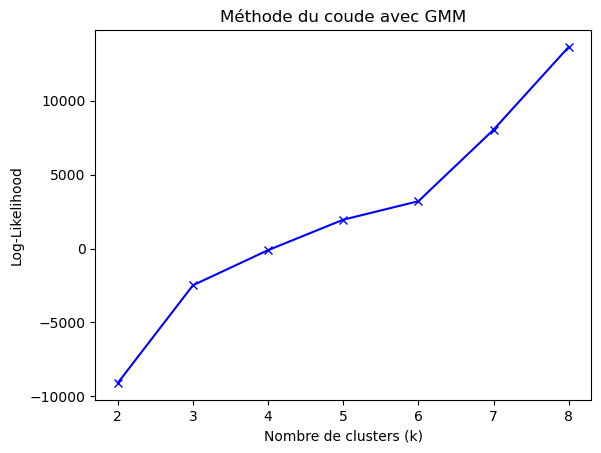

In [23]:
from pyspark.ml.clustering import GaussianMixture
import matplotlib.pyplot as plt

# Recherche du k optimal

# Liste pour stocker la log-vraisemblance
log_likelihoods = []
k_range = range(2, 9) # On teste de 2 à 8 clusters

for k in k_range:
    gmm = GaussianMixture().setK(k).setFeaturesCol("scaled_features").setSeed(42)
    model = gmm.fit(rfm_final)
    # Plus la valeur est élevée (proche de 0), mieux c'est
    summary = model.summary
    log_likelihoods.append(summary.logLikelihood)

# Visualisation (Méthode du coude sur la log-vraisemblance)
plt.plot(k_range, log_likelihoods, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Log-Likelihood')
plt.title('Méthode du coude avec GMM')
plt.show()

#### Méthode silhouette

Pour k = 2, le Score de Silhouette est : 0.9815
Pour k = 3, le Score de Silhouette est : 0.7134
Pour k = 4, le Score de Silhouette est : 0.7168
Pour k = 5, le Score de Silhouette est : 0.7850
Pour k = 6, le Score de Silhouette est : 0.6867
Pour k = 7, le Score de Silhouette est : 0.6973
Pour k = 8, le Score de Silhouette est : 0.6926
Pour k = 9, le Score de Silhouette est : 0.6249
Pour k = 10, le Score de Silhouette est : 0.6168


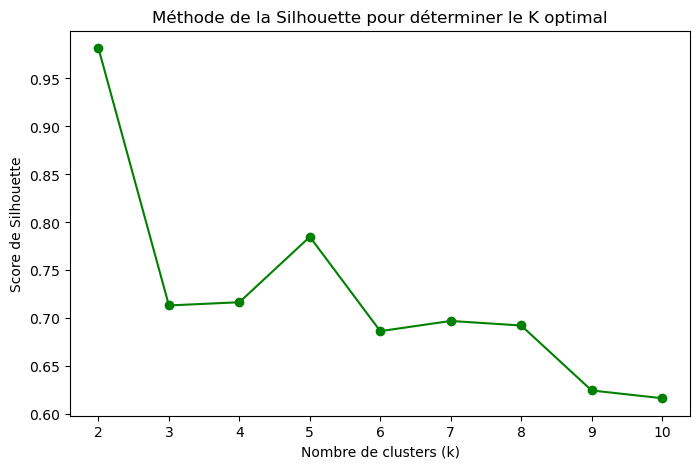

In [47]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler

# --- 2. Calcul du Score de Silhouette pour différents K ---
evaluator = ClusteringEvaluator(predictionCol="prediction", featuresCol="scaled_features", \
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

silhouette_scores = []

rfm_final.cache() # pour l'optimisation du calcul

for k in range(2, 11):
    # Entraînement du modèle
    kmeans = KMeans().setK(k).setSeed(42).setFeaturesCol("scaled_features")
    model = kmeans.fit(rfm_final)
    
    # Prédiction (assignation des clusters)
    predictions = model.transform(rfm_final)
    
    # Calcul du score
    score = evaluator.evaluate(predictions)
    silhouette_scores.append((k, score))
    print(f"Pour k = {k}, le Score de Silhouette est : {score:.4f}")

# --- 3. Affichage rapide des résultats ---
import matplotlib.pyplot as plt

k_values, scores = zip(*silhouette_scores)
plt.figure(figsize=(8, 5))
plt.plot(k_values, scores, 'go-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.title('Méthode de la Silhouette pour déterminer le K optimal')
plt.show()

#### Aperçu business avec K=5

In [24]:
from pyspark.ml.clustering import GaussianMixture
from pyspark.sql.functions import col, count, round, avg

# --- 1. Entraînement GMM pour k=5 ---
k = 5
gmm = GaussianMixture().setK(k).setSeed(42).setFeaturesCol("scaled_features")
gmm_model = gmm.fit(rfm_final)

# --- 2. Ajout des clusters ---
rfm_clustered = gmm_model.transform(rfm_final)

# --- 3. Taille totale du dataset ---
total_clients = rfm_clustered.count()

# --- 4. Calcul des moyennes RFM, taille et pourcentage par cluster ---
cluster_summary = rfm_clustered.groupBy("prediction").agg(
    round(avg("Recency"), 2).alias("Avg_Recency"),
    round(avg("Frequency"), 2).alias("Avg_Frequency"),
    round(avg("Monetary"), 2).alias("Avg_Monetary"),
    count("*").alias("Count")
).withColumn(
    "Percentage", round((col("Count") / total_clients) * 100, 2)
).orderBy("prediction")

# --- 5. Affichage du tableau final ---
cluster_summary.show(truncate=False)

+----------+-----------+-------------+------------+-----+----------+
|prediction|Avg_Recency|Avg_Frequency|Avg_Monetary|Count|Percentage|
+----------+-----------+-------------+------------+-----+----------+
|0         |33.77      |2.8          |761.8       |1200 |27.66     |
|1         |43.73      |28.27        |29362.21    |124  |2.86      |
|2         |136.6      |3.45         |1315.01     |933  |21.5      |
|3         |159.94     |1.0          |259.62      |1346 |31.02     |
|4         |14.57      |9.66         |3744.26     |736  |16.96     |
+----------+-----------+-------------+------------+-----+----------+



#### Centroïdes

In [36]:
# Moyennes (centroïdes) du GMM
for i, mu in enumerate(gmm_model.gaussiansDF.select("mean").collect()):
    print(f"Cluster {i} centroïde : {mu['mean']}")

Cluster 0 centroïde : [-0.5719550451173528,-0.2024473136000155,-0.14607952462024734]
Cluster 1 centroïde : [-0.4807202250203451,3.078974203196106,3.0168818970911384]
Cluster 2 centroïde : [0.3575564378004611,-0.09513861600823613,-0.08165868296212239]
Cluster 3 centroïde : [0.721996648868123,-0.42461487853248836,-0.19909790249591058]
Cluster 4 centroïde : [-0.7716796026331002,0.668615406512813,0.17952766221926703]


#### Visualisation des clusters PCA

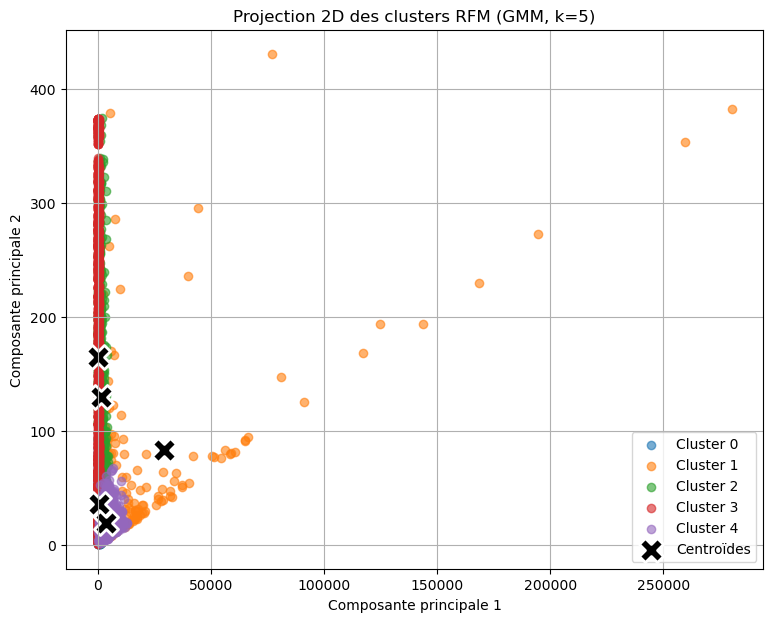

In [34]:
from pyspark.ml.feature import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ======================
# 1️⃣ PCA sur les vraies valeurs RFM
# ======================

pca = PCA(k=2, inputCol="raw_features", outputCol="pca_features")
pca_model = pca.fit(rfm_clustered)
pca_result = pca_model.transform(rfm_clustered)

# ======================
# 2️⃣ Conversion en pandas
# ======================

pca_pd = pca_result.select("pca_features", "prediction").toPandas()

pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda v: v[0])
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda v: v[1])

# ======================
# 3️⃣ Récupération et dé-standardisation des centroïdes
# ======================

# Centroïdes dans l’espace standardisé
centers_scaled = gmm_model.gaussiansDF.select("mean").collect()
centers_scaled = np.array([row["mean"] for row in centers_scaled])

# Récupérer moyenne et écart-type du StandardScaler
means = np.array(scaler_model.mean)
stds = np.array(scaler_model.std)

# Revenir aux vraies valeurs
centers_raw = centers_scaled * stds + means

# ======================
# 4️⃣ Projection PCA des centroïdes (même espace que raw)
# ======================

pc_matrix = np.array(pca_model.pc.toArray())
centers_projected = centers_raw.dot(pc_matrix)

centers_pca = pd.DataFrame(centers_projected, columns=["PC1", "PC2"])

# ======================
# 5️⃣ Visualisation
# ======================

plt.figure(figsize=(9,7))

# Clusters
for cluster in sorted(pca_pd["prediction"].unique()):
    subset = pca_pd[pca_pd["prediction"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

# Centroïdes
plt.scatter(
    centers_pca["PC1"],
    centers_pca["PC2"],
    s=300,
    marker="X",
    color="black",
    edgecolor="white",
    linewidth=2,
    label="Centroïdes"
)

plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection 2D des clusters RFM (GMM, k=5)")
plt.legend()
plt.grid(True)
plt.show()

#### Visualisation cluster 3D

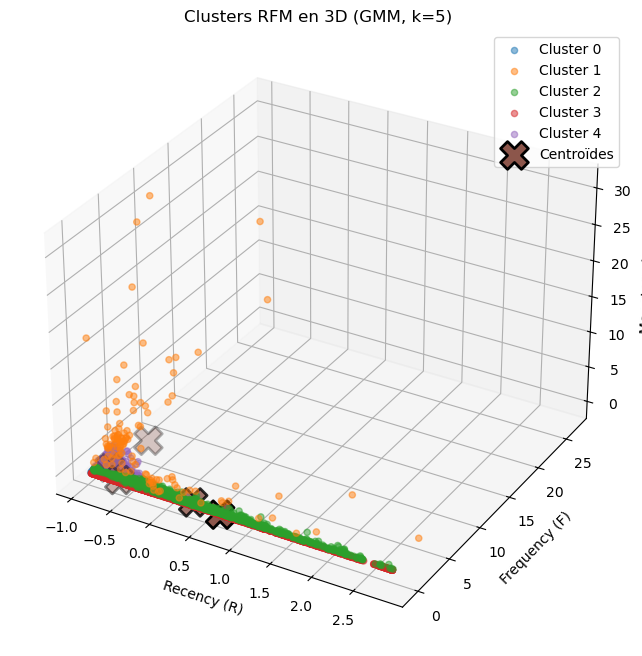

In [35]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.linalg import Vectors

# ======================
#  Conversion en pandas
# ======================

rfm_pd = rfm_clustered.select("scaled_features", "prediction").toPandas()

rfm_pd["R"] = rfm_pd["scaled_features"].apply(lambda v: v[0])
rfm_pd["F"] = rfm_pd["scaled_features"].apply(lambda v: v[1])
rfm_pd["M"] = rfm_pd["scaled_features"].apply(lambda v: v[2])

# ======================
#  Récupération des centroïdes
# ======================

centers = gmm_model.gaussiansDF.select("mean").collect()
centers_vectors = [row["mean"] for row in centers]

centroids_pd = pd.DataFrame(centers_vectors, columns=["R", "F", "M"])

# ======================
#  Graphique 3D
# ======================

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Clusters
for cluster in sorted(rfm_pd["prediction"].unique()):
    subset = rfm_pd[rfm_pd["prediction"] == cluster]
    ax.scatter(
        subset["R"],
        subset["F"],
        subset["M"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

# Centroïdes
ax.scatter(
    centroids_pd["R"],
    centroids_pd["F"],
    centroids_pd["M"],
    s=400,
    marker="X",
    edgecolor="black",
    linewidth=2,
    label="Centroïdes"
)

ax.set_xlabel("Recency (R)")
ax.set_ylabel("Frequency (F)")
ax.set_zlabel("Monetary (M)")
ax.set_title("Clusters RFM en 3D (GMM, k=5)")

ax.legend()
plt.show()

#### Scoring

In [46]:
from pyspark.sql import functions as F

# 1. Utilisation du modèle pour assigner les clusters
# .transform() crée automatiquement une colonne 'prediction'
predictions = gmm_model.transform(rfm_final)

# 2. On rend les résultats "lisibles" (Mapping)
# Selon l'analyse des moyennes qu'on a faite précédemment
df_classe = predictions.withColumn("Segment_Client", 
    F.when(F.col("prediction") == 1, "VIP (Grosses dépenses)")
     .when(F.col("prediction") == 4, "Fidèles (Récent & Régulier)")
     .when(F.col("prediction") == 0, "Nouveaux / Occasionnels")
     .when(F.col("prediction") == 2, "À réveiller (Inactifs)")
     .otherwise("Perdus / Hibernants")
)

# 3. Sélection des colonnes essentielles pour ton export ou ton analyse
# Remplace 'CustomerID' par le nom exact de ta colonne d'identifiant
resultat_final = df_classe.select(
    "CustomerID", 
    "Recency", 
    "Frequency", 
    "Monetary", 
    "prediction", 
    "Segment_Client"
)

# Affichage des premiers résultats
resultat_final.show(10)

+----------+--------+---------+--------+----------+--------------------+
|CustomerID| Recency|Frequency|Monetary|prediction|      Segment_Client|
+----------+--------+---------+--------+----------+--------------------+
|     15619| 10.1917|        1|   336.4|         3| Perdus / Hibernants|
|     17389|  0.1333|       34|31833.68|         1|VIP (Grosses dépe...|
|     14450|180.1278|        3|  483.25|         2|À réveiller (Inac...|
|     15727| 16.0097|        7| 5159.06|         4|Fidèles (Récent &...|
|     15790|  9.9146|        1|  218.75|         3| Perdus / Hibernants|
|     13285| 22.9799|        4| 2709.12|         4|Fidèles (Récent &...|
|     14570|280.0778|        2|  218.06|         2|À réveiller (Inac...|
|     16574| 71.0076|        1|  451.44|         3| Perdus / Hibernants|
|     13623| 30.0347|        5|  727.74|         0|Nouveaux / Occasi...|
|     15957|  31.025|        1|  428.89|         3| Perdus / Hibernants|
+----------+--------+---------+--------+----------+

#### Analyse de segmentos

In [47]:
# Calcul des moyennes par segment
analysis = rfm_clustered.groupBy("prediction") \
    .agg(
        F.avg("Recency").alias("Moy_Recency"),
        F.avg("Frequency").alias("Moy_Frequency"),
        F.avg("Monetary").alias("Moy_Monetary"),
        F.count("prediction").alias("Nombre_Clients")
    ).orderBy("prediction")

analysis.show()

+----------+------------------+------------------+------------------+--------------+
|prediction|       Moy_Recency|     Moy_Frequency|      Moy_Monetary|Nombre_Clients|
+----------+------------------+------------------+------------------+--------------+
|         0|  33.7691643333333| 2.799166666666667| 761.8047499999992|          1200|
|         1| 43.72641935483872|28.266129032258064|29362.208548387087|           124|
|         2|136.60231382636655|  3.45016077170418|1315.0067095391228|           933|
|         3| 159.9427772659734|               1.0|259.62481426448716|          1346|
|         4|14.572313722826095|           9.65625|3744.2568885869587|           736|
+----------+------------------+------------------+------------------+--------------+



C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_5640\1000641959.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cluster_counts, x='prediction', y='count', palette='viridis')


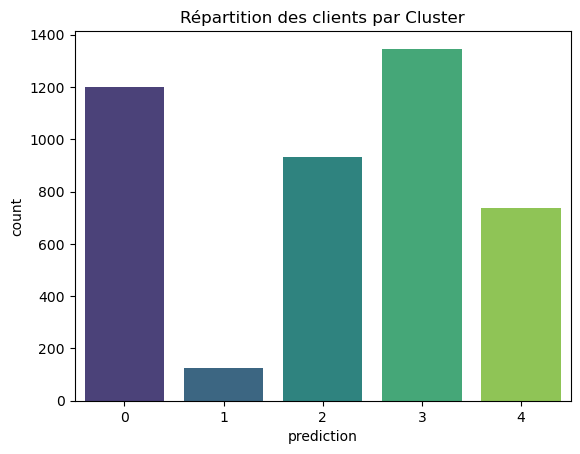

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compter les clients par cluster
cluster_counts = rfm_clustered.groupBy("prediction").count().toPandas()

sns.barplot(data=cluster_counts, x='prediction', y='count', palette='viridis')
plt.title("Répartition des clients par Cluster")
plt.show()

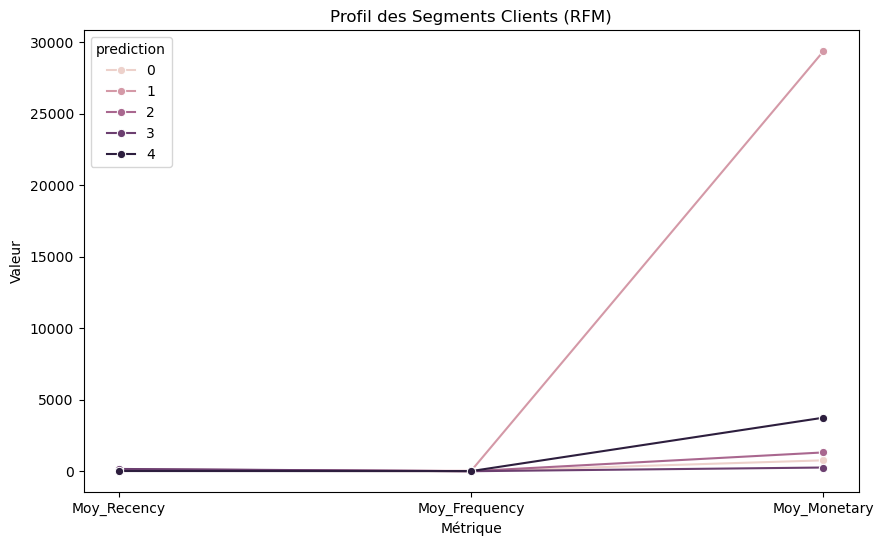

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Conversion en Pandas pour le plot
df_plot = analysis.toPandas()

# Normalisation rapide pour comparer les variables sur une même échelle
df_melted = pd.melt(df_plot, id_vars=['prediction', 'Nombre_Clients'], 
                    value_vars=['Moy_Recency', 'Moy_Frequency', 'Moy_Monetary'],
                    var_name='Métrique', value_name='Valeur')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='Métrique', y='Valeur', hue='prediction', marker='o')
plt.title("Profil des Segments Clients (RFM)")
plt.show()